# The AFT briefing — France's debt stock, its interest bill, and the 2027 map

Companion to [`../reports/briefing_FRA_AFT_2026-09/briefing.html`](../reports/briefing_FRA_AFT_2026-09/briefing.html)
(D-S12-001). The briefing was written for a meeting with the Agence France
Trésor's Chief Economist on 18 September 2026; this notebook regenerates every
chart and table in it from [`../deliverables/`](../deliverables) and nothing
else, so the numbers can be re-run when the register is refreshed.

Three modules do the work:

* `ggfiscal.report.briefing_fra` — the descriptive charts: the register against
  the AFT's totals, the maturity profile and redemption calendar, the maturity
  trend, the average coupon against the marginal yield, interest by security,
  the OAT–Bund spread, issuance by bucket; plus `key_figures.csv`.
* `ggfiscal.debt.simulate` — the yield-path simulation `DEBT_KICKOFF.md` §1 said
  the register was shaped for: the stock rolled forward year by year under a
  **declared** primary-balance path, spread path, bill stock and tenor mix, with
  interest feeding back into the deficit. Six scenarios: the current path, the
  four 2027 configurations (Le Pen / Philippe × majority / hung) and one rupture
  stress. Every parameter is a number in `BASELINE` or `SCENARIOS`.
* `ggfiscal.report.briefing_fra_scenarios` — the scenario charts, the spread-vs-
  volume decomposition of each scenario's interest gap, and the mark-to-market
  sensitivity (duration) of the stock.

Nothing here enters the canonical layer or the bundle: the outputs live under
`reports/briefing_FRA_AFT_2026-09/`.


In [1]:
import io
from pathlib import Path

import pandas as pd
from IPython.display import Image as Image_display, display
from PIL import Image

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "deliverables" / "debt_securities.csv").exists())
OUT = ROOT / "reports" / "briefing_FRA_AFT_2026-09" / "figures"

from ggfiscal.report import briefing_fra, briefing_fra_scenarios
from ggfiscal.debt import simulate as sim

FIGS = briefing_fra.render_all(OUT)
FIGS.update(briefing_fra_scenarios.render_all(OUT))
pd.set_option("display.width", 160)


def show(key, colours=48, width=880):
    """Display a rendered PNG quantised to a small palette (D-S9-004: keep the
    notebook renderable on GitHub)."""
    im = Image.open(FIGS[key]).convert("RGB")
    if im.width > width:
        im = im.resize((width, round(im.height * width / im.width)), Image.LANCZOS)
    small = im.quantize(colours, dither=Image.Dither.NONE)
    buf = io.BytesIO(); small.save(buf, format="PNG", optimize=True)
    display(Image_display(data=buf.getvalue()))


print(f"{len(FIGS)} charts rendered into {OUT.relative_to(ROOT)}")

19 charts rendered into reports/briefing_FRA_AFT_2026-09/figures


## 1. Where the stock stands

The register at the AFT's latest snapshot (10 September 2026) against the office's own totals, then the maturity profile, the redemption calendar, and what fell due each year since 2000 (`refinancing_by_year.csv`) to put the 2027–2029 redemptions in context.

In [2]:
pd.read_csv(OUT / 'key_figures.csv').set_index('metric').value.round(3).to_frame().T.T

,value
metric,
stock_2026-09-10_total_nominal_eur_bn,2862.3
stock_2026-09-10_total_uplifted_eur_bn,2936.6
stock_2026-09-10_bill_nominal_eur_bn,217.5
stock_2026-09-10_bill_uplifted_eur_bn,217.5
stock_2026-09-10_fixed_bullet_nominal_eur_bn,2404.0
...,...
gf01_7_2029_eur_bn,107.9
gf01_7_2031_pct_gdp,3.743
gf01_7_2031_eur_bn,132.2


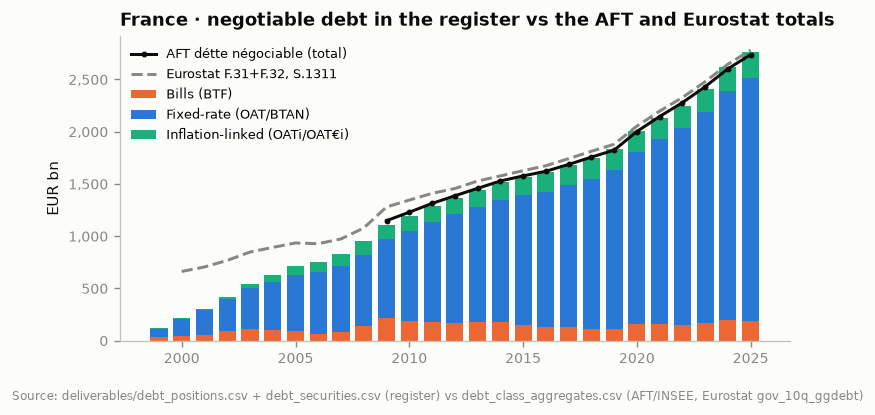

In [3]:
show('stock_by_class')

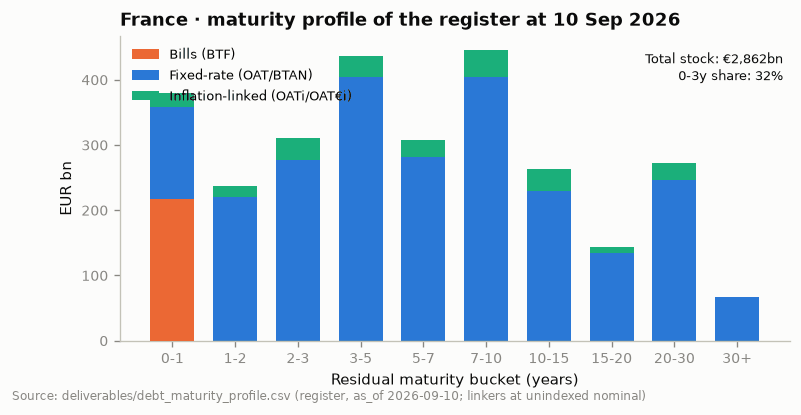

In [4]:
show('maturity_profile')

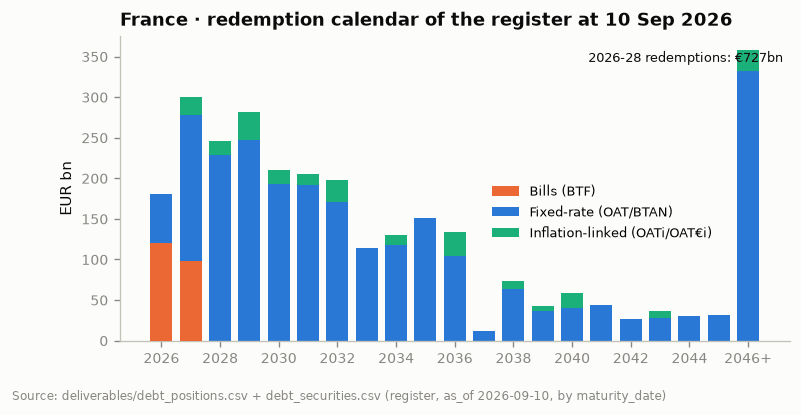

In [5]:
show('redemption_calendar')

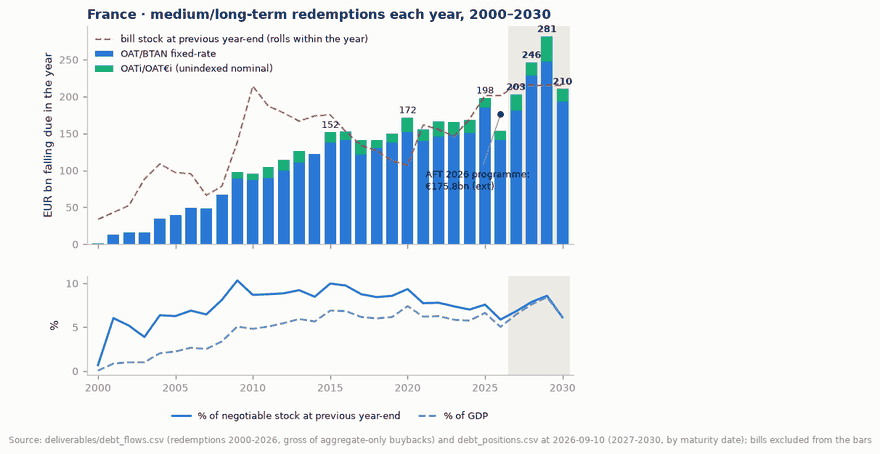

In [6]:
show('refinancing_history')

## 2. The interest bill

General-government interest (the strict `GF01_7`, with its EC AMECO / DSM leg), the ledger, the average coupon against the marginal yield, and interest by security against the official totals.

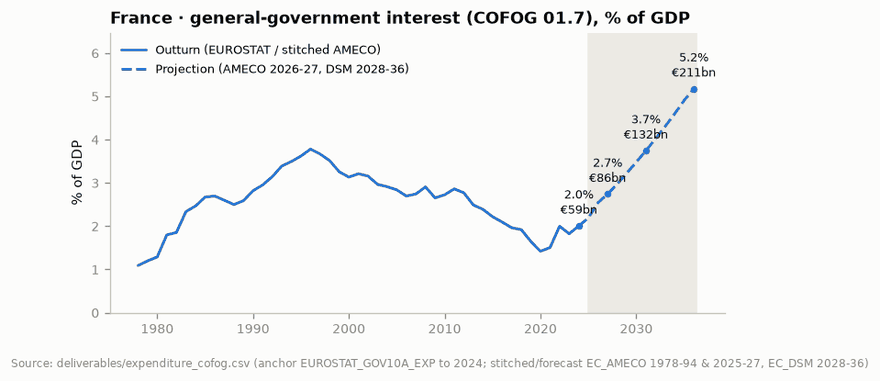

In [7]:
show('interest_gg')

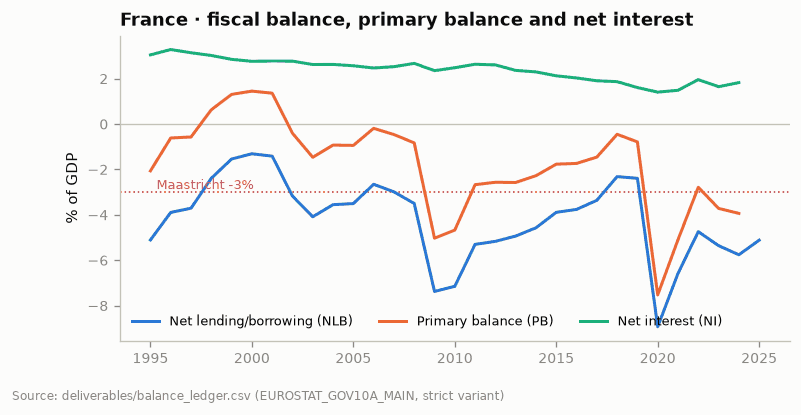

In [8]:
show('ledger')

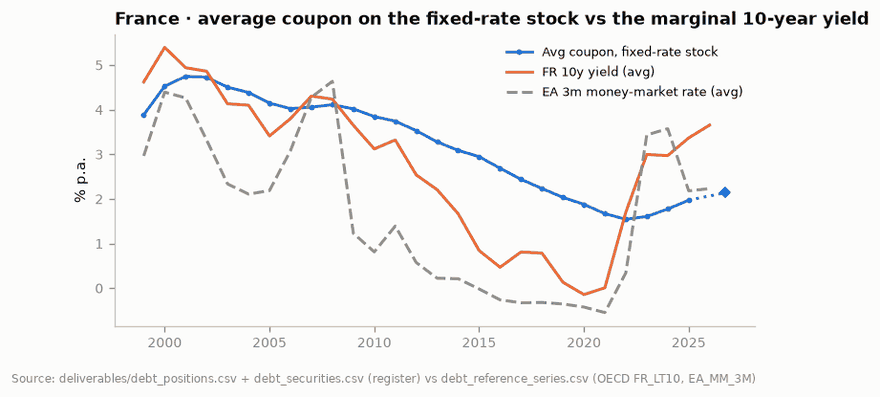

In [9]:
show('coupon_vs_yield')

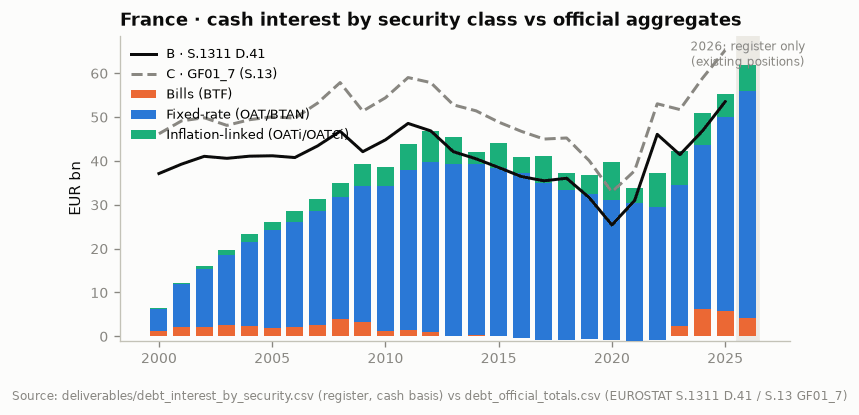

In [10]:
show('interest_by_security')

## 3. The shortening stock

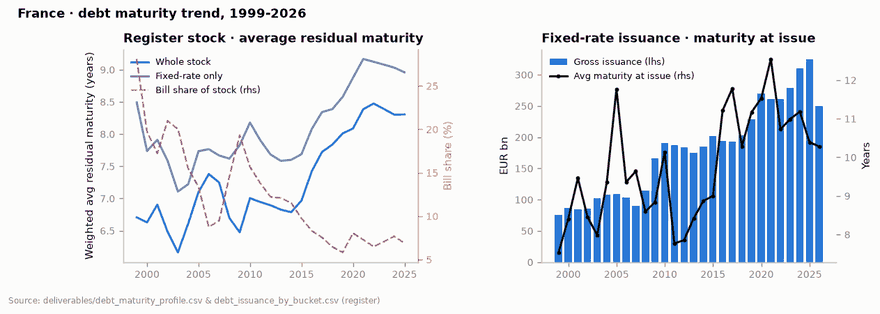

In [11]:
show('maturity_trend')

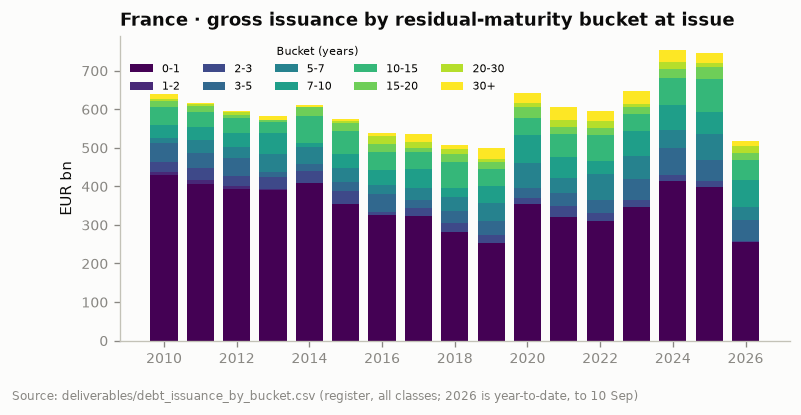

In [12]:
show('issuance_by_bucket')

## 4. The simulation

The engine's calibrations, computed from the bundle rather than declared: the
share of the general-government deficit the État's negotiable debt has
financed (Δ(F.31+F.32) over −NLB, 2015–2025) and the wedge between the
register's interest and `GF01_7` in 2025.

In [13]:
sim.calibration()

{'net_issuance_over_deficit_2015_2025': 0.904,
 'register_cash_interest_2025_bn': 55.2,
 'gf01_7_2025_bn': 65.2,
 'wedge_2025_bn': 10.1,
 'wedge_2025_pct_gdp': 0.34}

The declared scenarios, exactly as the engine reads them.

In [14]:
pd.DataFrame([{"scenario": s.name, "label": s.label, "primary balance dev (pp GDP)": s.pb_deviation,
               "10y spread (bp)": s.spread_bp, "bill stock (EUR bn)": s.btf_stock, "tenor tilt": s.maturity_tilt}
              for s in sim.SCENARIOS]).set_index("scenario")

,label,primary balance dev (pp GDP),10y spread (bp),bill stock (EUR bn),tenor tilt
scenario,,,,,
current,Current path,{2026: 0.0},"{2026: 85, 2027: 85, 2028: 80, 2029: 75, 2030:...",{2026: 215.0},0.00
philippe_majority,"Philippe, majority","{2027: 0.0, 2028: 0.3, 2029: 0.6, 2030: 0.9, 2...","{2026: 85, 2027: 80, 2028: 60, 2029: 50, 2030:...",{2026: 215.0},0.00
philippe_hung,"Philippe, hung Assembly","{2027: 0.0, 2028: -0.1, 2029: -0.2, 2030: -0.3...","{2026: 85, 2027: 85, 2028: 80, 2029: 80, 2030:...",{2026: 215.0},0.00
lepen_majority,"Le Pen, majority","{2027: 0.0, 2028: -1.2, 2029: -1.5, 2030: -1.5}","{2026: 85, 2027: 110, 2028: 150, 2029: 140, 20...","{2026: 215.0, 2027: 230.0, 2028: 260.0, 2029: ...",0.04
lepen_hung,"Le Pen, hung Assembly","{2027: 0.0, 2028: -0.6, 2029: -0.8, 2030: -1.0}","{2026: 85, 2027: 100, 2028: 120, 2029: 120, 20...","{2026: 215.0, 2027: 225.0, 2028: 240.0}",0.02
lepen_rupture,"Le Pen, majority, rupture (stress)","{2027: 0.0, 2028: -1.5, 2029: -2.0, 2030: -2.0}","{2026: 85, 2027: 130, 2028: 250, 2029: 220, 20...","{2026: 215.0, 2027: 240.0, 2028: 300.0, 2029: ...",0.08


In [15]:
RES = pd.read_csv(OUT / "scenarios_FRA.csv")
cols = ["label", "year", "spread_bp", "oat_10y_pct", "gg_interest_bn", "gg_interest_pct_gdp",
        "deficit_pct_gdp", "debt_pct_gdp", "mlt_gross_issuance_bn", "avg_coupon_fixed_pct"]
RES[RES.year.isin([2027, 2028, 2030, 2032, 2035])][cols].round(2).set_index(["label", "year"])

spread_bp  oat_10y_pct  gg_interest_bn  gg_interest_pct_gdp  deficit_pct_gdp  debt_pct_gdp  mlt_gross_issuance_bn  \
label                              year                                                                                                                      
Current path                       2027      85.00         4.25           86.85                 2.76             5.06        119.32                 355.99   
                                   2028      80.00         4.20           98.32                 3.03             4.93        120.77                 395.05   
                                   2030      70.00         4.10          121.00                 3.51             4.61        123.10                 393.25   
                                   2032      70.00         4.10          144.21                 3.95             4.35        124.68                 459.40   
                                   2035      70.00         4.10          169.42                 4.24             4.54        127.07                 505.42   
Philippe, majority                 2027      80.00         4.20           86.75                 2.75             5.05        119.32                 355.90   
                                   2028      60.00         4.00           97.55                 3.01             4.61        120.45                 385.59   
                                   2030      45.00         3.85          116.88                 3.39             3.59        121.12                 361.65   
                                   2032      45.00         3.85          135.48                 3.71             3.11        120.43                 416.30   
                                   2035      45.00         3.85          153.08                 3.84             3.14        119.24                 443.06   
Philippe, hung Assembly            2027      85.00         4.25           86.85                 2.76             5.06        119.32                 355.99   
                                   2028      80.00         4.20           98.38                 3.03             5.03        120.88                 398.02   
                                   2030      75.93         4.16          121.92                 3.54             4.94        123.72                 403.38   
                                   2032      78.17         4.18          146.77                 4.02             4.82        126.17                 475.59   
                                   2035      82.23         4.22          175.30                 4.39             5.09        129.96                 529.28   
Le Pen, majority                   2027     110.00         4.50           86.96                 2.76             5.06        119.32                 341.09   
                                   2028     150.01         4.90          100.32                 3.09             6.19        122.04                 401.89   
                                   2030     138.70         4.79          131.32                 3.81             6.41        127.71                 457.46   
                                   2032     149.23         4.89          164.89                 4.51             6.41        132.97                 557.03   
                                   2035     166.91         5.07          209.44                 5.25             7.05        141.52                 665.32   
Le Pen, hung Assembly              2027     100.00         4.40           86.93                 2.76             5.06        119.32                 346.06   
                                   2028     120.01         4.60           99.46                 3.06             5.56        121.41                 398.60   
                                   2030     119.57         4.60          127.52                 3.70             5.80        125.76                 434.30   
                                   2032     126.61         4.67          157.92            

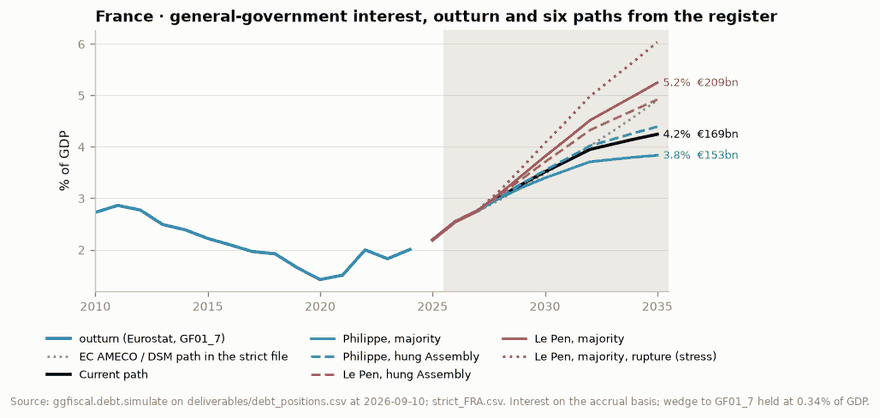

In [16]:
show('scen_interest')

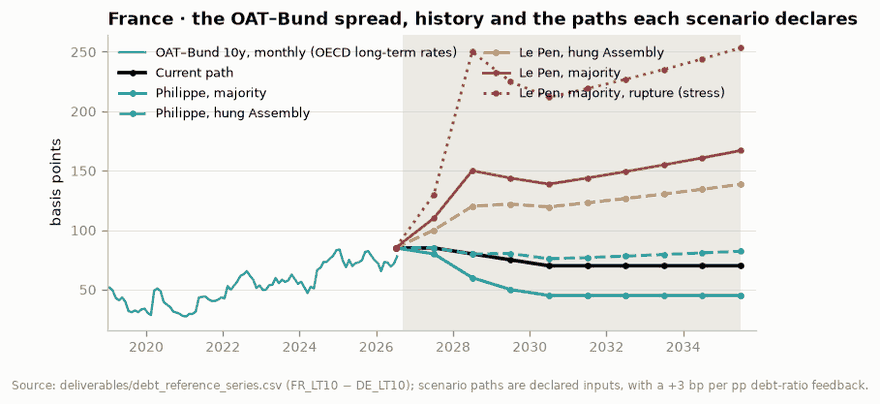

In [17]:
show('scen_spread')

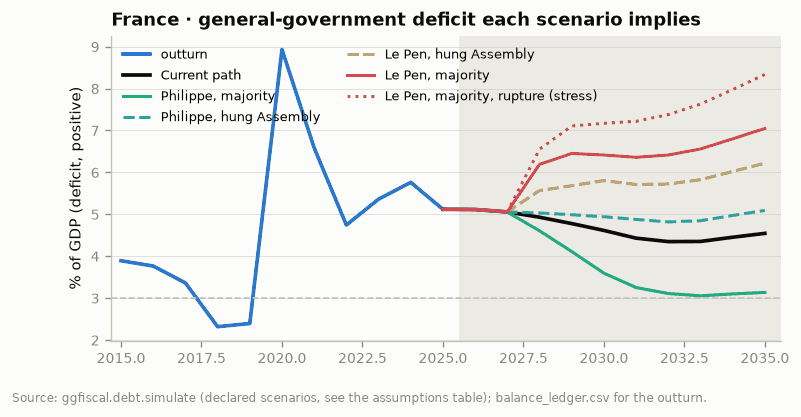

In [18]:
show('scen_deficit')

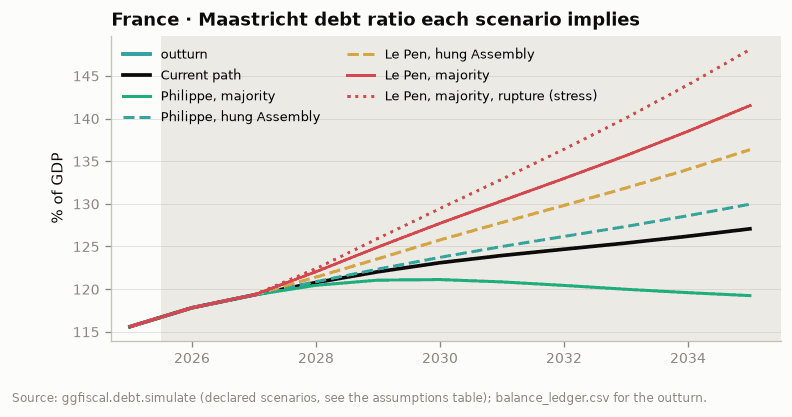

In [19]:
show('scen_debt')

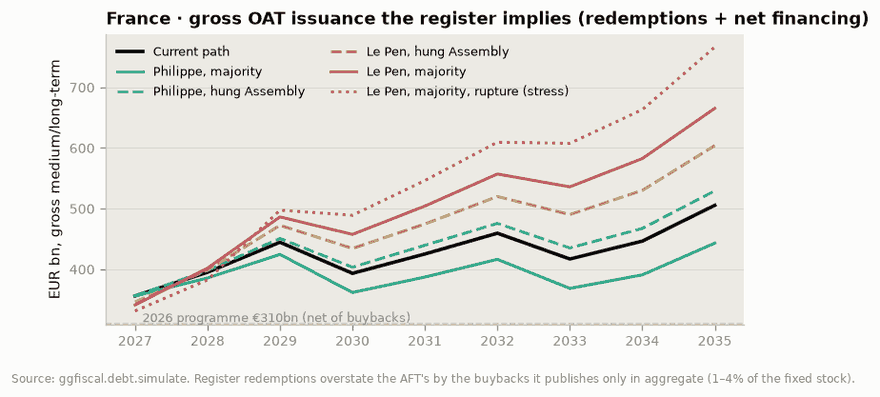

In [20]:
show('scen_issuance')

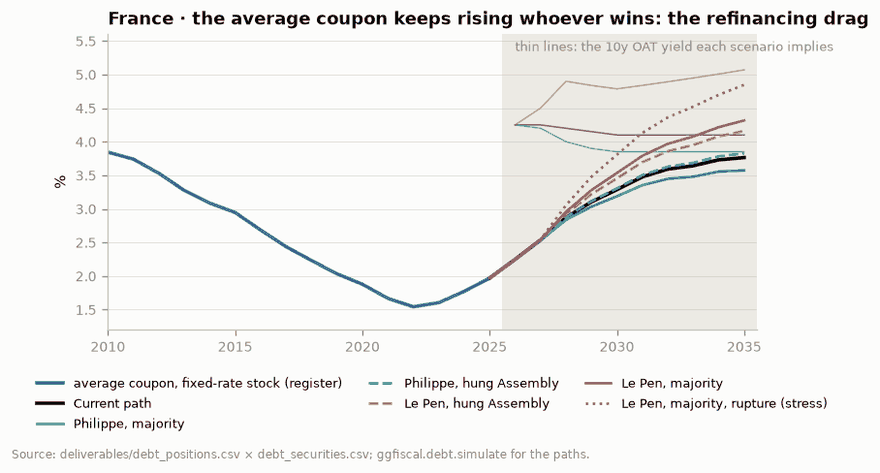

In [21]:
show('scen_coupon')

### The wrong-way loop, decomposed

Each scenario's extra interest over the current path, split by re-running one
lever at a time: the spread alone (price), the primary balance and issuance
strategy alone (volume), and what is left (the interaction: extra issuance
that the extra interest itself requires, priced at the wider spread).

In [22]:
pd.read_csv(OUT / 'scenario_decomposition.csv').round(1).set_index(['label', 'year'])

scenario  gap_bn  spread_effect_bn  volume_effect_bn  interaction_bn
label                              year                                                                               
Philippe, majority                 2030  philippe_majority    -4.1              -2.5              -1.7             0.1
                                   2035  philippe_majority   -16.3              -7.6              -9.3             0.6
Philippe, hung Assembly            2030      philippe_hung     0.9               0.3               0.6             0.0
                                   2035      philippe_hung     5.0               1.4               3.5             0.0
Le Pen, majority                   2030     lepen_majority     9.9               7.7               2.2             0.1
                                   2035     lepen_majority    33.7              20.3              12.0             1.4
Le Pen, hung Assembly              2030         lepen_hung     6.3               4.9               1.3             0.1
                                   2035         lepen_hung    23.3              14.4               8.1             0.8
Le Pen, majority, rupture (stress) 2030      lepen_rupture    18.6              17.3               1.8            -0.5
                                   2035      lepen_rupture    61.8              45.7              13.8             2.3

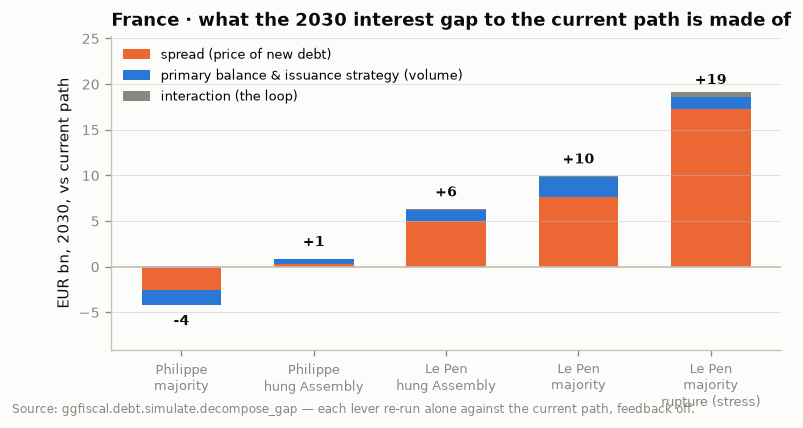

In [23]:
show('scen_decomposition')

## 5. Rate sensitivity of the stock

Every bond in the register priced at the Bund curve plus 90 bp (linkers on
real yields), with its modified duration; the sum is what a 100 bp move does
to the market value of the OAT stock, and where in the curve it sits.

In [24]:
sim.duration_summary(90.0)

{'market_value_bn': np.float64(2419.0),
 'nominal_bn': np.float64(2719.0),
 'modified_duration_years': np.float64(6.23),
 'loss_per_100bp_bn': np.float64(151.0),
 'loss_per_100bp_pct_gdp': np.float64(4.93)}

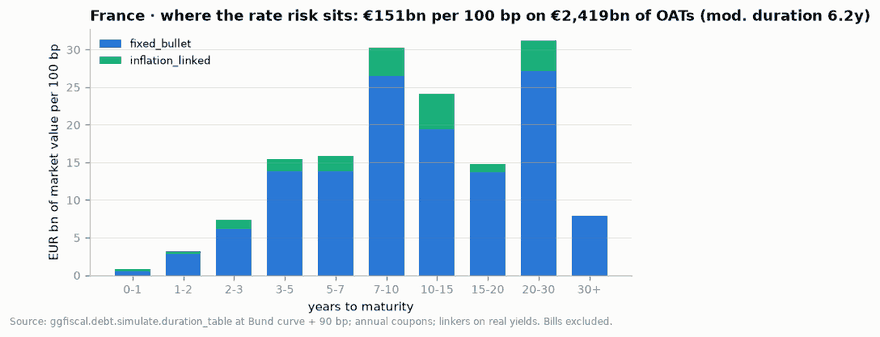

In [25]:
show('duration')

In [26]:
d = sim.duration_table(90.0)
d.sort_values("value_per_bp_mn", ascending=False).head(12)[["name", "class", "nominal_bn", "years_to_maturity", "yield_pct", "price", "modified_duration", "value_per_bp_mn"]].round(2)

,name,class,nominal_bn,years_to_maturity,yield_pct,price,modified_duration,value_per_bp_mn
18,"OAT 1,25 % 25 mai 2036",fixed_bullet,71.35,9.71,4.28,76.71,8.69,47.59
9,"OAT 4,50 % 25 avril 2041",fixed_bullet,43.45,14.62,4.47,102.01,10.39,46.05
69,"OAT 3,50% 25 novembre 2035",fixed_bullet,59.06,9.21,4.24,97.19,7.45,42.75
57,"OAT 3,50 % 25 novembre 2033",fixed_bullet,63.25,7.21,4.08,99.22,6.06,38.00
65,"OAT 3,20 % 25 mai 2035",fixed_bullet,54.71,8.70,4.20,93.74,7.31,37.48
26,"OAT 1,25 % 25 mai 2034",fixed_bullet,65.04,7.70,4.12,81.74,7.03,37.37
13,"OAT 3,25 % 25 mai 2045",fixed_bullet,31.66,18.70,4.58,84.51,13.07,34.97
10,"OAT 4,00 % 25 avril 2060",fixed_bullet,22.84,33.62,4.78,88.49,16.88,34.13
63,"OAT 3,00 % 25 novembre 2034",fixed_bullet,52.35,8.21,4.16,94.41,6.89,34.03
6,"OAT 4,00 % 25 avril 2055",fixed_bullet,23.99,28.62,4.76,89.68,15.76,33.90
